In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2
%load_ext memory_profiler

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# Read the mhd file from data
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd
import mpl_interactions as pli

import matplotlib.pyplot as plt
from scipy.ndimage import zoom, gaussian_filter

In [3]:
nrrd_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
nrrd_to_mhd(nrrd_file,force=True)
phantom = patient_data.patient_phantom(nrrd_file, 1e10, reload=True, sim_num=7)
phantom.out_dir ='/home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_7'
phantom.load_ggems()

[2024-05-24 16:55:45,473] {utils.py:626} INFO - Directory /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan already exists, but is being overwriten
[2024-05-24 16:55:45,473] {utils.py:631} INFO - Creating directory 2_Stereo_CNS_Scan
[2024-05-24 16:55:46,728] {utils.py:718} INFO - The spacing is [1.25     0.761719 0.761719]
[2024-05-24 16:55:46,729] {utils.py:720} INFO - The origin is [-229.5 -195.  -195. ]
[2024-05-24 16:55:46,729] {utils.py:721} INFO - The shape is (296, 512, 512)
[2024-05-24 16:55:48,796] {utils.py:491} INFO - Loading density data from file
[2024-05-24 16:55:48,799] {utils.py:931} INFO -     Saved SchneiderMaterialsWeight1 atten to file in data/mu_over_rho/SchneiderMaterialsWeight1.csv
[2024-05-24 16:55:48,800] {utils.py:491} INFO - Loading density data from file
[2024-05-24 16:55:48,802] {utils.py:931} INFO -     Saved SchneiderMaterialsWeight2 atten to file in data/mu_over_rho/SchneiderMaterialsWeight2.csv
[2024-05-24 16:55:48,803] {utils.py:4

/home/jericho/Software/gecco/gecco/spectrum.py:121: RuntimeWarning: divide by zero encountered in log
  log_y = np.log(yy)


[2024-05-24 16:55:50,269] {utils.py:743} INFO - Phantom Created
To load the phantom from the mhd file use the following command: 
phantom = patient_phantom.patient_phantom("/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd",[nparticles])
[2024-05-24 16:55:50,294] {patient_data.py:69} INFO - Reloading phantom
[2024-05-24 16:55:50,295] {patient_data.py:154} INFO - Found existing directory. Using mhd file 2_Stereo_CNS_Scan_phantom.mhd
[2024-05-24 16:55:50,684] {patient_data.py:184} INFO - Phantom loaded from pickle file fastmc_1e07_1angles.pkl
[2024-05-24 16:55:50,685] {patient_data.py:189} INFO - Loading ggems files

[2024-05-24 16:55:50,687] {patient_data.py:220} INFO - Using the first detector layer ggems files
[2024-05-24 16:55:50,687] {patient_data.py:243} INFO - No flood file found for the first layer
[2024-05-24 16:55:50,687] {patient_data.py:258} INFO - ggems files loaded
[2024-05-24 16:55:50,687] {patient_data.py:259} INFO -     Sc

In [4]:
# phantom_bak = phantom.phantom.copy()
# density_bak = phantom.density.copy()
# geomet_bak = phantom.geomet

# phantom.phantom = phantom_bak
# phantom.density = density_bak

In [5]:
phantom.phantom = phantom.phantom[:,60:,:]
phantom.density = phantom.density[:,60:,:]

In [6]:
phantom.geomet.nVoxel = np.array(phantom.phantom.shape)
phantom.geomet.sVoxel = phantom.geomet.nVoxel*phantom.geomet.dVoxel

In [7]:
# phantom.geomet.dDetector = np.array([0.392,0.392])
# phantom.geomet.nDetector = (phantom.geomet.sDetector/phantom.geomet.dDetector).astype(int)

In [8]:
# %%memit
# Source spectrum
spectrum = fc.calculate_spectrum_sp(100,12)

# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

phantom.xx, phantom.yy = spectrum.get_points()
%mprun -f phantom.run_gecco phantom.run_gecco(1e11,815,conv_on=False)

# det = fc.Detector(spectrum,'CsI-784-micrometer')
# phantom.simulate(det,spectrum,2,1e10,filter)

[2024-05-24 16:55:56,131] {patient_data.py:605} INFO - Making a list of angles
[2024-05-24 16:55:56,134] {patient_data.py:633} INFO - Detector matching specifications: CsI-784-micrometer
[2024-05-24 16:55:56,147] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/full_fan_alt.dat
[2024-05-24 16:55:57,373] {ggems_simulate.py:581} INFO - Running Simulations
[2024-05-24 16:55:57,374] {ggems_simulate.py:609} INFO -     Simulating 10 keV
[2024-05-24 16:55:57,398] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight2 is 10.349854284535223
[2024-05-24 16:55:57,412] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight3 is 5.647085846302243
[2024-05-24 16:55:57,428] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight4 is 6.434291404998359
[2024-05-24 16:55:57,443] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for Schneider

: 

In [46]:
phantom.correct_intensity(ml=False,crop=40)

In [16]:
# These are the beam hardening corrections
fits = np.load('/home/jericho/1-Workspace/3-jupyter_notebooks_patient/7-bhc/fits.npy')

In [47]:
phantom.sim_angles = np.linspace(0,2*np.pi,45)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.25) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
phantom.reconstruct_ggems(algo="FDK") # recon2structs creates phantom.img => reconstructed image

In [32]:
# Turn on for the beam hardening correction
for i in range(phantom.gecco_projections.shape[2]):
    p = np.poly1d(fits[i])
    phantom.gecco_projections[:,:,i] = p(phantom.gecco_projections[:,:,i])

NameError: name 'fits' is not defined

In [48]:
import SimpleITK as sitk

ct_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
cbct_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Unnamed_Series_1.nrrd'

ct = sitk.ReadImage(ct_file)
cbct = sitk.ReadImage(cbct_file)

ct = sitk.GetArrayFromImage(ct)
cbct = sitk.GetArrayFromImage(cbct)

cbct = np.flip(cbct, axis=2)


In [74]:

# To match the CBCT geometry:

# phantom.geomet.nVoxel = np.array(cbct.shape)
# phantom.geomet.dVoxel = np.array([0.995,0.51119073851527,0.51119073851527])
# phantom.geomet.sVoxel = phantom.geomet.nVoxel * phantom.geomet.dVoxel


In [60]:
water_cbct = np.mean(cbct[79,236:250,285:300])
air_cbct = np.mean(cbct[79,0:10,0:10])
cbct_hu = (cbct - water_cbct)/(water_cbct-air_cbct) * 1000

img = phantom.img[139].squeeze()
water = np.mean(img[236:250,285:300])
air = np.mean(img[0:10,0:10])
# convert to HU using the water calibration
img = (img - water)/(water) * 1000
img = gaussian_filter(img,1)


In [61]:
# np.save('815_proj_HU_noise',img)

In [71]:
# np.save('815_proj_HU_no_noise',img)

In [72]:
img_noise = np.load('815_proj_HU_noise.npy')
img = np.load('815_proj_HU_no_noise.npy')

Mean difference: 14.52 HU


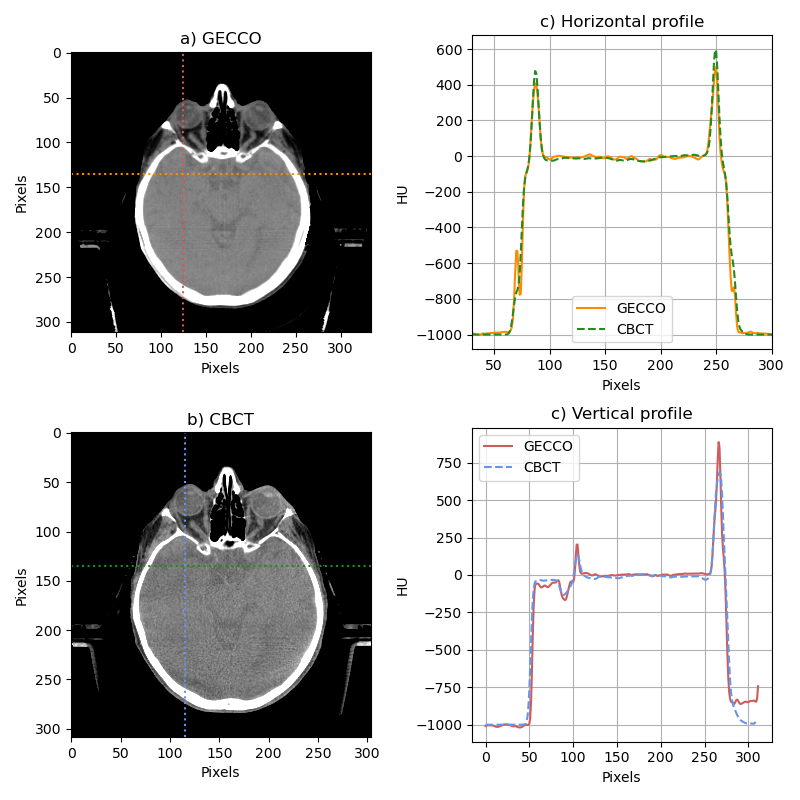

In [83]:
plt.figure(figsize=(8,8))

cbct_hu_clean = zoom(cbct_hu[79:81].mean(axis=0),0.511/0.761)
cbct_hu2 = gaussian_filter(cbct_hu_clean,2)
index = 115
index2 = 124
crop = [60,80,88,90]

plt.subplot(2,2,1)
plt.imshow(img_noise[crop[0]:-crop[1],crop[2]:-crop[3]], cmap='gray', vmin=-200, vmax=200)
# indicate the profile with a red dotted axis horizontal line
plt.axhline(135, color='darkorange', linestyle=':')
plt.axvline(index2, color='indianred', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('a) GECCO')
plt.subplot(2,2,3)
plt.imshow(cbct_hu_clean[15:-20,10:-30], cmap='gray', vmin=-200, vmax=200)
plt.axhline(135, color='forestgreen', linestyle=':')
plt.axvline(index, color='cornflowerblue', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('b) CBCT')
# plt.axis('off')

plt.subplot(2,2,2)
profile = img[300,:]

# x1 = np.arange(crop[2], img.shape[1]-crop[3])
# x2 = np.linspace(0, 512,cbct_hu2.shape[1])
plt.plot(img[135+crop[0],crop[2]:-crop[3]], label='GECCO', c='darkorange')
plt.plot(cbct_hu2[135 + 15], label='CBCT', c = 'forestgreen', linestyle='--')
plt.xlim(30,300)
# plt.xlim(100,410)
plt.legend()
plt.title('c) Horizontal profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()

plt.subplot(2,2,4)
plt.plot(img[crop[0]:-crop[1],index2+crop[2]], label='GECCO', c='indianred')
plt.plot(cbct_hu2[15:-20,index+12], label='CBCT', c = 'cornflowerblue', linestyle='--')

# plt.xlim(100,410)
plt.legend()
plt.title('c) Vertical profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()
# Interpolate the profile to the same length
from scipy.interpolate import interp1d

# f1 = interp1d(x1, img[199,crop[2]:-crop[3]])
# f2 = interp1d(x2, cbct_hu2[127,10:-20])

# x = np.linspace(100,410,512)
# plt.figure()
# plt.plot(x, f1(x), label='GECCO', c='darkorange')
# plt.plot(x, f2(x), label='CBCT', c = 'forestgreen', linestyle='--')
# plt.legend()
# plt.colorbar(label='HU')   
prof = np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10])
# Calculate the difference between the two profiles
mean_diff = np.mean(prof[img[135+crop[0],crop[2]:-crop[3]]>-250])
std_diff = np.std(np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10]))

print(f'Mean difference: {mean_diff:.2f} HU')

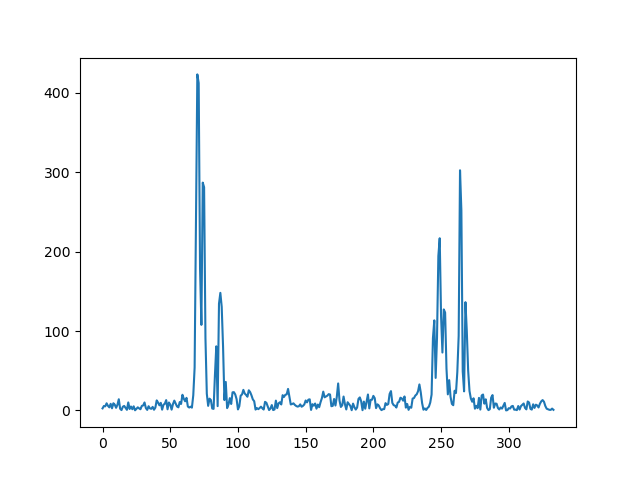

In [40]:
plt.figure()
plt.plot(prof[prof>-250])

In [31]:
# fig = plt.figure(figsize=(10,5))
hi_res_bowtie_HU = phantom.img/np.mean(phantom.img[130:160,220:-220, 220:-220])
hi_res_bowtie_HU = (hi_res_bowtie_HU-(1) + np.mean(cbct[70:80,220:-220, 220:-220])/1000)*1000

# scale the values below -500 quadratically towards -1000
hi_res_bowtie_HU[hi_res_bowtie_HU < -500] = -1000 + (hi_res_bowtie_HU[hi_res_bowtie_HU < -500] + 1000)**(2)/500

# Make a circular mask about the center of the image and set all values outside a radius of 300 to -1000
x, y, z = np.ogrid[:hi_res_bowtie_HU.shape[0], :hi_res_bowtie_HU.shape[1], :hi_res_bowtie_HU.shape[2]]
mask = (x - hi_res_bowtie_HU.shape[0] / 2) ** 2 + (y - hi_res_bowtie_HU.shape[1] / 2) ** 2 + (z - hi_res_bowtie_HU.shape[2] / 2) ** 2 > 220 ** 2
hi_res_bowtie_HU[mask] = -1000

w = 355
l = 0

In [17]:

phantom.reconstruct_ggems(algo='FDK',filt='hamming')

13.399944031576325
6.521133229350339
9.960538630463333


/tmp/ipykernel_411338/1995990029.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


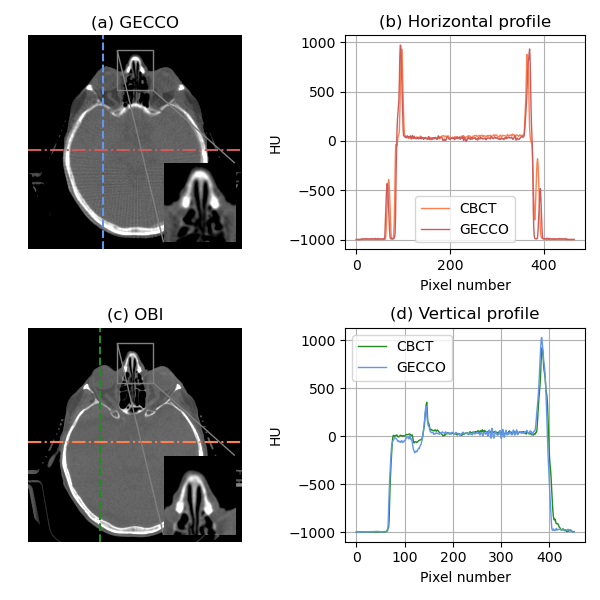

In [20]:
w, l = 1500, 200

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

ind_hline = 256
ind_vline = 256 - 70
ind_hline_rec = 256

ind_vline_rec = 256 - 70 + 6

crops = [25,55,40,40]

plt.figure(figsize=(6,6))
# plt.subplot(311)
# plt.imshow(np.fliplr(ct[139,125:-90,100:-100]), cmap='gray',vmin=l-w/2, vmax=l+w/2)
# plt.axis('off')
# plt.title('CT')
# Add a colorbar with a lable
# plt.colorbar(label='Hounsfield Units')
plt.subplot(223)
plt.imshow(cbct[79,crops[0]:-crops[1],crops[2]:-crops[3]], cmap='gray',vmin=l-w/2, vmax=l+w/2)
plt.axvline(ind_vline - crops[2], color='forestgreen', linestyle='--')
plt.axhline(ind_hline - crops[0], color='coral', linestyle='-.')

plt.axis('off')
plt.title('(c) OBI')
from scipy.ndimage import gaussian_filter

cbct_79_bak = cbct[79].copy()
# cbct[79] = cbct_79_bak
# cbct[79] = gaussian_filter(cbct[79],1.5)
# Add an inset axis to the image of the top left corner 
# ax_inset = plt.axes([0.3, 0.6, 0.1, 0.1])
# ax_inset.imshow(cbct[79,70:150,220:-220], cmap='gray',vmin=l-w/2, vmax=l+w/2)
# ax_inset.axis('off')
ax = plt.gca()
# Do the same thing but using zoomed_inset_axes 
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(cbct[79,crops[0]:-crops[1],crops[2]:-crops[3]], cmap='gray',vmin=l-w/2, vmax=l+w/2)
ax_inset.set_ylim(150-40,70-40)
ax_inset.set_xlim(220-40,512-220-40)
ax_inset.axis('off')
# Mark the region of the inset axis on the main image
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")

# Indicate the region of the inset axis on the main image 
# plt.plot([70,150,150,70,70],[220,220,512-220,512-220,220], color='r')

plt.subplot(221)
plt.imshow(hi_res_bowtie_HU[83,crops[0]:-crops[1],crops[2]:-crops[3]], cmap='gray',vmin=l-w/2, vmax=l+w/2)
plt.axvline(ind_vline_rec - crops[2], color='cornflowerblue', linestyle='--')
plt.axhline(ind_hline_rec - crops[0], color='indianred', linestyle='-.')
plt.axis('off')
plt.title('(a) GECCO')
ax = plt.gca()
# Do the same thing but using zoomed_inset_axes 
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(hi_res_bowtie_HU[82,crops[0]:-crops[1],crops[2]:-crops[3]], cmap='gray',vmin=l-w/2, vmax=l+w/2)
ax_inset.set_ylim(150-40,70-40)
ax_inset.set_xlim(220-40,512-220-40)
ax_inset.axis('off')
# Mark the region of the inset axis on the main image
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")
plt.subplot(222)
plt.title('(b) Horizontal profile')
# plot a profile through the center of the images
# plt.plot(ct[139,ind_hline,100:-100], label='CT', color='black')
# xx = np.linspace()

nm=9
plt.plot(cbct[79,ind_hline-nm:ind_hline+nm,20:-6-20].mean(axis=0), label='CBCT', color='coral',lw=1)
plt.plot(hi_res_bowtie_HU[82,ind_hline_rec - nm:ind_hline_rec+nm,20+6:-20].mean(axis=0), label='GECCO', color='indianred',lw=1)
# Plot a red dotted line at the center of the image
plt.xlabel('Pixel number')
plt.ylabel('HU')
plt.grid('on')
plt.legend()

plt.subplot(224)
plt.title('(d) Vertical profile')
# plot a profile through the center of the images
# plt.plot(ct[139,125+30:-30-90,ind_vline], label='CT', color='black')
plt.plot(cbct[79,30:-30,ind_vline-nm:ind_vline+nm].mean(axis=1), label='CBCT', color='forestgreen',lw=1)
plt.plot(hi_res_bowtie_HU[82,20:-40,ind_vline_rec - nm:ind_vline_rec+nm].mean(axis=1), label='GECCO', color='cornflowerblue',lw=1)
# plt.axvline(256, color='r', linestyle='--')
plt.legend()
# plt.title('(d) Horizontal profile')
plt.xlabel('Pixel number')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()

# print the difference between the cbct and the fastcat reconstructions along the horizontal and vertical profiles
print(100*np.mean(np.abs(cbct[79,30:-30,ind_vline-nm:ind_vline+nm].mean(axis=1) 
                     - hi_res_bowtie_HU[82,30:-30,ind_vline_rec - 
                                        nm:ind_vline_rec+nm].mean(axis=1))/
                                        np.max(cbct[79,30:-30,ind_vline-nm:ind_vline+nm].mean(axis=1))))
print(100*np.mean(np.abs(cbct[79,ind_hline-nm:ind_hline+nm,20:-6-20].mean(axis=0)
                        - hi_res_bowtie_HU[82,ind_hline_rec - nm:ind_hline_rec+nm,20+6:-20].mean(axis=0))/
                                            np.max(cbct[79,ind_hline-nm:ind_hline+nm,20:-6-20].mean(axis=0))))
# define these as variables
mean_diff_hor = 100*np.mean(np.abs(cbct[79,30:-30,ind_vline-nm:ind_vline+nm].mean(axis=1)
                        - hi_res_bowtie_HU[82,30:-30,ind_vline_rec - 
                                            nm:ind_vline_rec+nm].mean(axis=1))/
                                            np.max(cbct[79,30:-30,ind_vline-nm:ind_vline+nm].mean(axis=1)))
mean_diff_ver = 100*np.mean(np.abs(cbct[79,ind_hline-nm:ind_hline+nm,20:-6-20].mean(axis=0)
                        - hi_res_bowtie_HU[82,ind_hline_rec - nm:ind_hline_rec+nm,20+6:-20].mean(axis=0))/
                                            np.max(cbct[79,ind_hline-nm:ind_hline+nm,20:-6-20].mean(axis=0)))

print(np.mean([mean_diff_hor, mean_diff_ver]))
# plt.savefig('cbct_fastmc_comparison.png', dpi=300)